## Portfolio Risk Analysis with Value-at-Risk (VaR) and Expected Shortfall (ES)

### Objective

The goal of this project is to analyze the **market risk of a multi-asset portfolio** using several standard quantitative risk measures.

We consider a portfolio composed of five large-cap US stocks from two sectors:
- **Technology**: Apple, Microsoft, Amazon
- **Banking/Finance**: JPMorgan Chase, Goldman Sachs

The project focuses on the following risk measures:

- **Historical Value-at-Risk (VaR)**
- **Parametric VaR (Variance-Covariance approach)**
- **Monte Carlo VaR**
- **Expected Shortfall (ES)**

These measures are computed for:
- **95% confidence level**
- **99% confidence level**

We also extend the analysis to a **10-day regulatory horizon** using the square-root-of-time scaling rule.

---

### Financial interpretation

Value-at-Risk (VaR) answers the following question:
*What is the maximum loss that should not be exceeded over a given time horizon, with a given confidence level?*

For example, a **1-day 95% VaR of 2%** means that:

- with **95% confidence**, the portfolio is not expected to lose more than **2% in one day**
- equivalently, there is a **5% probability** of losing **more than 2%**

Expected Shortfall goes one step further:
*If losses do exceed the VaR threshold, what is the average loss in those worst cases?*

This makes Expected Shortfall a more informative measure of **tail risk**.

---

### Methods used

1. Historical VaR
This method uses the empirical distribution of past returns directly.  
No normality assumption is imposed.

2. Parametric VaR
This method assumes portfolio returns are approximately **normally distributed**, using:
- sample mean
- sample standard deviation

3. Monte Carlo VaR
This method simulates a large number of portfolio returns from a chosen distribution (here, normal), then estimates the loss quantile numerically.

4. Expected Shortfall
This is the average loss beyond the VaR threshold, based here on the historical distribution of returns.

### Portfolio composition

The portfolio weights are fixed as follows:
- AAPL: 25%
- MSFT: 25%
- AMZN: 20%
- JPM: 15%
- GS: 15%

The total portfolio value is set to:

- **10,000** (in dollars or euros depending on interpretation)

This allows us to convert risk measures expressed in **returns** into **currency losses**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf

# Display settings for cleaner output
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

### 1. Define the portfolio and the study period

We begin by specifying:
- the list of assets
- their portfolio weights
- the sample period
- the total portfolio value

The weights must sum to 1 because we assume the full capital is invested.

In [3]:
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'GS']  # 5 assets
weights = np.array([0.25, 0.25, 0.20, 0.15, 0.15])  # must sum to 1

start_date = '2024-01-01'
end_date   = '2025-01-01'

portfolio_value = 10_000  # used to convert VaR from return to currency

# Sanity check
assert abs(weights.sum() - 1.0) < 1e-8, "Weights must sum to 1."

print("Tickers:", tickers)
print("Weights:", weights)
print("Sum of weights:", weights.sum())
print("Study period:", start_date, "to", end_date)
print("Portfolio value:", portfolio_value)

Tickers: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'GS']
Weights: [0.25 0.25 0.2  0.15 0.15]
Sum of weights: 1.0
Study period: 2024-01-01 to 2025-01-01
Portfolio value: 10000


### 2. Download market data and compute daily returns

We download daily closing prices from Yahoo Finance using `yfinance`.

Then we compute simple daily returns:

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

where:
- $P_t$ is the price at day $t$
- $R_t$ is the return over one trading day

After that, we compute the **portfolio return** as the weighted sum of individual asset returns:

$$
R_{p,t} = \sum_{i=1}^{n} w_i R_{i,t}
$$

This gives us a time series of portfolio daily returns.

In [ ]:
# Download daily closing prices
prices = yf.download(tickers, start=start_date, end=end_date)['Close'].dropna()

# Compute simple daily returns
returns = prices.pct_change().dropna()

# Portfolio daily returns = weighted sum of asset returns
portfolio_returns = returns.dot(weights)

print("Price data (first 5 rows):")
display(prices.head())

print("\nAsset returns (first 5 rows):")
display(returns.head())

print("\nPortfolio returns (first 5 rows):")
display(portfolio_returns.head())

C:\Users\ebens\AppData\Local\Temp\ipykernel_35096\3912827302.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed

Price data (first 5 rows):


Ticker,AAPL,AMZN,GS,JPM,MSFT
Date,,,,,
2024-01-02,183.731277,149.929993,369.588898,163.009354,364.589447
2024-01-03,182.355606,148.470001,363.392578,162.298874,364.324005
2024-01-04,180.039658,144.570007,364.496735,163.375916,361.709076
2024-01-05,179.317154,145.240005,367.818542,164.195618,361.522278
2024-01-08,183.652115,149.100006,370.121918,163.957336,368.344788



Asset returns (first 5 rows):


Ticker,AAPL,AMZN,GS,JPM,MSFT
Date,,,,,
2024-01-03,-0.007487,-0.009738,-0.016765,-0.004359,-0.000728
2024-01-04,-0.012700,-0.026268,0.003038,0.006636,-0.007177
2024-01-05,-0.004013,0.004634,0.009113,0.005017,-0.000516
2024-01-08,0.024175,0.026577,0.006262,-0.001451,0.018872
2024-01-09,-0.002263,0.015225,-0.013167,-0.007906,0.002936



Portfolio returns (first 5 rows):


Date
2024-01-03   -0.008422
2024-01-04   -0.009216
2024-01-05    0.002653
2024-01-08    0.016553
2024-01-09   -0.000139
dtype: float64

### 3. Define helper functions for VaR and ES

We now define the functions needed to compute the different risk measures.
### Historical VaR
The historical VaR at level $ \alpha $ is based on the empirical quantile of returns:
$$
\text{VaR}_{\alpha}^{\text{hist}} = -Q_\alpha(R)
$$
where:
- $Q_\alpha(R)$ is the $ \alpha $-quantile of historical portfolio returns
Since the left tail corresponds to losses, the quantile is usually negative.  
We multiply by -1 so that VaR is reported as a positive loss magnitude.

### Parametric VaR

Under the normality assumption:
$$
R \sim \mathcal{N}(\mu, \sigma^2)
$$

the VaR is:
$$
\text{VaR}_{\alpha}^{\text{param}} = -(\mu + z_\alpha \sigma)
$$

where:
- $ \mu $ is the sample mean return
- $ \sigma $ is the sample standard deviation
- $ z_\alpha $ is the $ \alpha $-quantile of the standard normal distribution

### Monte Carlo VaR

We simulate many returns from a normal distribution:

$$
\tilde{R}^{(j)} \sim \mathcal{N}(\mu, \sigma^2)
$$

for $j = 1, \dots, N$, then estimate the empirical $ \alpha $-quantile of these simulated returns.

### Expected Shortfall

Historical Expected Shortfall is defined as the average return in the worst $ \alpha \% $ of cases:

$$
ES_\alpha = -\mathbb{E}[R \mid R \leq Q_\alpha(R)]
$$

This measure is especially useful because it captures the **severity of tail losses**, not only the cutoff point.

In [5]:
def historical_var(r: pd.Series, alpha=0.05):
    """
    Historical VaR at level alpha.
    Returns a positive number representing the magnitude of loss.
    """
    q = r.quantile(alpha)
    return -q

def parametric_var(r: pd.Series, alpha=0.05):
    """
    Parametric VaR under the normality assumption.
    VaR = -(mu + z_alpha * sigma)
    """
    mu = r.mean()
    sigma = r.std(ddof=1)
    z = norm.ppf(alpha)
    return -(mu + z * sigma)

def monte_carlo_var(r: pd.Series, alpha=0.05, n_sims=100_000, random_state=0):
    """
    Monte Carlo VaR using simulated normal returns with
    sample mean and sample standard deviation.
    """
    rng = np.random.default_rng(random_state)
    mu = r.mean()
    sigma = r.std(ddof=1)
    sims = rng.normal(loc=mu, scale=sigma, size=n_sims)
    q = np.quantile(sims, alpha)
    return -q

def expected_shortfall_historical(r: pd.Series, alpha=0.05):
    """
    Historical Expected Shortfall (CVaR):
    average loss among the worst alpha% returns.
    """
    cutoff = r.quantile(alpha)
    tail_losses = r[r <= cutoff]
    return -tail_losses.mean()

def to_currency(var_as_return, portfolio_value):
    """
    Convert a VaR or ES expressed as a return into a monetary amount.
    """
    return var_as_return * portfolio_value

### 4.Compute daily VaR and Expected Shortfall

We compute the risk measures for two confidence levels: 95%/99%

Equivalently, in terms of tail probability:
- 95% confidence corresponds to  $ \alpha=0.05 $
- 99% confidence corresponds to $ \alpha=0.01 $

For each level, we compute:
- Historical VaR
- Parametric VaR
- Monte Carlo VaR
- Historical Expected Shortfall

Results are reported in:
- return units
- currency units

In [6]:
levels = {'95%': 0.05, '99%': 0.01}
results = []

for label, alpha in levels.items():
    hv = historical_var(portfolio_returns, alpha)
    pv = parametric_var(portfolio_returns, alpha)
    mv = monte_carlo_var(portfolio_returns, alpha, n_sims=100_000, random_state=42)
    es = expected_shortfall_historical(portfolio_returns, alpha)

    results.append({
        'Confidence': label,
        'Historical VaR (return)': hv,
        'Parametric VaR (return)': pv,
        'Monte Carlo VaR (return)': mv,
        'Expected Shortfall (return)': es,
        'Historical VaR (currency)': to_currency(hv, portfolio_value),
        'Parametric VaR (currency)': to_currency(pv, portfolio_value),
        'Monte Carlo VaR (currency)': to_currency(mv, portfolio_value),
        'Expected Shortfall (currency)': to_currency(es, portfolio_value),
    })

results_df = pd.DataFrame(results)

print("=== Daily VaR / ES Results ===")
display(results_df)

=== Daily VaR / ES Results ===


,Confidence,Historical VaR (return),Parametric VaR (return),Monte Carlo VaR (return),Expected Shortfall (return),Historical VaR (currency),Parametric VaR (currency),Monte Carlo VaR (currency),Expected Shortfall (currency)
0,95%,0.016510,0.015982,0.016125,0.024860,165.097426,159.822119,161.249853,248.597369
1,99%,0.030672,0.023193,0.023375,0.037609,306.720051,231.933290,233.749429,376.093887


### 5. Interpret the daily results

The table above provides different views of the same portfolio risk.

### Historical VaR
This uses the actual empirical distribution of returns.  
It reflects past observed market behavior directly and does not assume a theoretical distribution.

### Parametric VaR
This is simpler and widely used, but it assumes returns are approximately normal.  
If returns are skewed or fat-tailed, this method may underestimate or overestimate risk.

### Monte Carlo VaR
This method is flexible and simulation-based.  
In this implementation, it still relies on the normality assumption, but it approximates the quantile numerically using many simulated scenarios.

### Expected Shortfall
Expected Shortfall is always at least as large as VaR at the same confidence level, because it measures the average loss in the worst cases, rather than the threshold itself.


### 6. Compute 10-day VaR and ES

In regulatory and risk-management contexts, risk is often measured over a longer horizon such as **10 trading days**.

A common approximation is the **square-root-of-time rule**:

$$
\text{Risk}_{T} \approx \text{Risk}_{1} \times \sqrt{T}
$$

Thus, for a 10-day horizon:

$$
\text{Risk}_{10d} \approx \text{Risk}_{1d} \times \sqrt{10}
$$

This scaling is based on assumptions such as:
- independent returns
- identical distribution through time
- stable volatility

These assumptions are not always realistic in practice, but the rule remains widely used as a first approximation.

In [7]:
scale_10d = np.sqrt(10)

results_10d = results_df.copy()

for col in results_10d.columns:
    if 'return' in col or 'currency' in col:
        results_10d[col] = results_10d[col] * scale_10d

print("=== 10-Day VaR / ES (sqrt(10) scaled) ===")
display(results_10d)

=== 10-Day VaR / ES (sqrt(10) scaled) ===


,Confidence,Historical VaR (return),Parametric VaR (return),Monte Carlo VaR (return),Expected Shortfall (return),Historical VaR (currency),Parametric VaR (currency),Monte Carlo VaR (currency),Expected Shortfall (currency)
0,95%,0.052208,0.050540,0.050992,0.078613,522.083901,505.401916,509.916807,786.133906
1,99%,0.096993,0.073344,0.073918,0.118931,969.933965,733.437460,739.180596,"1,189.313296"


### 7. Visualize the return distribution and the 95% historical VaR cutoff

To better understand the risk profile of the portfolio, we plot the distribution of daily returns.

The vertical dashed line corresponds to the **historical 5th percentile**, which defines the **95% historical VaR threshold**.

Interpretation:
- most returns lie to the right of this cutoff
- the area to the left corresponds to the worst 5% of observed daily outcomes
- this region captures the tail events associated with large losses

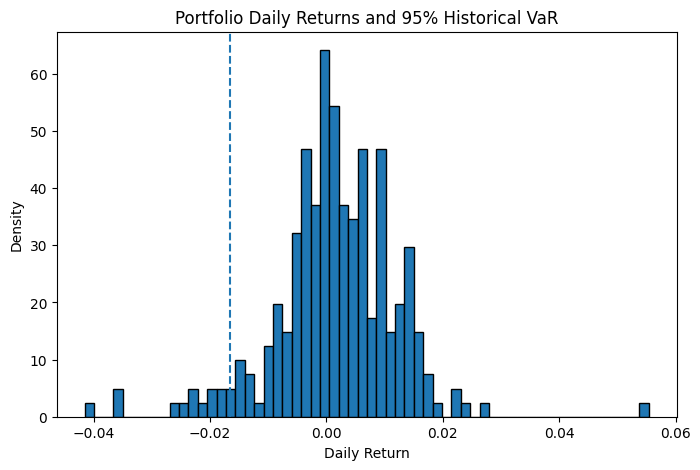

In [8]:
alpha = 0.05
hv_95 = historical_var(portfolio_returns, alpha)
cutoff_95 = -hv_95  # return threshold, usually negative

plt.figure(figsize=(8, 5))
plt.hist(portfolio_returns, bins=60, edgecolor='black', density=True)
plt.axvline(cutoff_95, linestyle='--')
plt.title("Portfolio Daily Returns and 95% Historical VaR")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.show()

### 8. Descriptive statistics of portfolio returns

Before concluding, it is useful to look at a few summary statistics of the portfolio return series:
- mean
- standard deviation
- minimum
- maximum
- skewness
- kurtosis

These statistics help us evaluate whether the normality assumption used in the parametric and Monte Carlo VaR approaches is reasonable.

In [9]:
stats = pd.DataFrame({
    'Mean': [portfolio_returns.mean()],
    'Std Dev': [portfolio_returns.std(ddof=1)],
    'Min': [portfolio_returns.min()],
    'Max': [portfolio_returns.max()],
    'Skewness': [portfolio_returns.skew()],
    'Kurtosis': [portfolio_returns.kurt()]
})

print("=== Descriptive Statistics of Portfolio Returns ===")
display(stats)

=== Descriptive Statistics of Portfolio Returns ===


,Mean,Std Dev,Min,Max,Skewness,Kurtosis
0,0.001423,0.010581,-0.041495,0.055386,-0.221269,3.993314


### 9. Comments on model limitations

Although this analysis is useful and standard in quantitative finance, it has several limitations.

*Historical window limitation:*
-depends entirely on the selected sample period.  
-If the historical window is too calm or too turbulent, the estimate may be misleading.

*Normality assumption:*
real financial returns often exhibit: skewness, excess kurtosis, volatility clustering

*Simplified Monte Carlo model:*
Monte Carlo simulation is based on a normal distribution calibrated from sample mean and volatility.  
A more advanced implementation could use:
- multivariate normal simulation
- GARCH-type volatility models
- t-distributions
- copulas for dependence structure
 
*Square-root-of-time approximation:*
The 10-day scaling rule assumes iid returns and stable variance.  

*No transaction costs or rebalancing:*
The portfolio weights are fixed and no rebalancing strategy is considered.  
Transaction costs, liquidity effects, and dynamic portfolio adjustment are ignored.

### Conclusion

This project implemented a complete **portfolio risk analysis framework** based on daily market data for a diversified portfolio of five major US stocks.

Using Historical VaR, Parametric VaR, Monte Carlo VaR, and Expected Shortfall, the analysis provided several complementary perspectives on downside risk.

The results illustrate the following key ideas:

- Portfolio risk must be assessed using multiple measures, since different methods rely on different assumptions.
- Historical VaR is data-driven and reflects realized market behavior directly.
- Parametric VaR is simple and computationally efficient, but depends on the normality assumption.
- Monte Carlo VaR is more flexible and can be extended to richer stochastic models.
- Expected Shortfall is particularly valuable because it captures the average severity of losses in the tail.

From a financial point of view, this notebook shows that risk analysis is not only about measuring volatility, but about understanding the distribution of losses.